In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [60]:
df = pd.read_excel("student_learning_dataset.xlsx")

In [26]:
df.head(10)

,student_id,course_id,age,gender,ethnicity,study_time_weekly,absences,test_preparation,math_score,reading_score,writing_score,science_score,extracurricular,learning_style
0,1,C104,20,Male,Group C,13,2,Completed,99,96,83,86,Yes,Visual
1,2,C105,18,Male,Group B,13,12,Completed,86,100,68,85,No,Visual
2,3,C103,20,Male,Group A,9,2,NaN,83,82,87,67,Yes,Visual
3,4,C105,19,Male,Group C,15,2,Completed,96,100,100,100,No,Kinesthetic
4,5,C105,17,Male,Group B,12,2,NaN,89,77,83,81,Yes,Auditory
5,6,C102,20,Female,Group B,16,9,Completed,100,94,76,90,No,Visual
6,7,C103,17,Female,Group B,17,1,Completed,89,93,99,91,Yes,Auditory
7,8,C103,18,Female,Group C,6,4,NaN,74,73,89,68,Yes,Auditory
8,9,C103,17,Female,Group D,8,7,NaN,71,83,76,63,No,Auditory
9,10,C105,18,Female,Group C,15,3,Completed,85,95,100,88,No,Kinesthetic


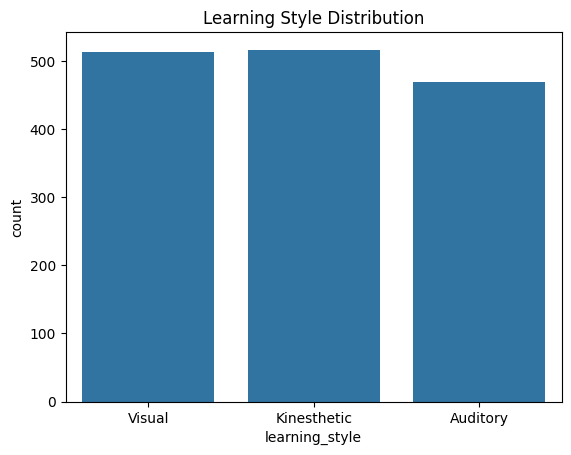

In [27]:
sns.countplot(x="learning_style", data=df)
plt.title("Learning Style Distribution")
plt.show()


### **Distribution of Learning Styles**

**The distribution indicates that certain learning styles are more common among students than others. This imbalance suggests that learning strategies should not be one-size-fits-all, and personalized approaches may be required to address the needs of different learner groups effectively.**

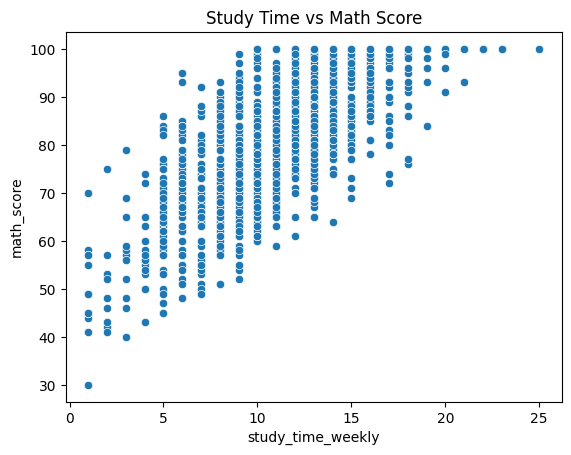

In [42]:
sns.scatterplot(x="study_time_weekly", y="math_score", data=df)
plt.title("Study Time vs Math Score")
plt.show()


### **Study Time and Academic Performance**

**Students who dedicate more hours to weekly study consistently achieve higher scores in mathematics. The positive relationship indicates that increased study time directly contributes to better understanding and performance. However, the improvement is gradual rather than extreme, suggesting that consistency matters more than short bursts of effort.**

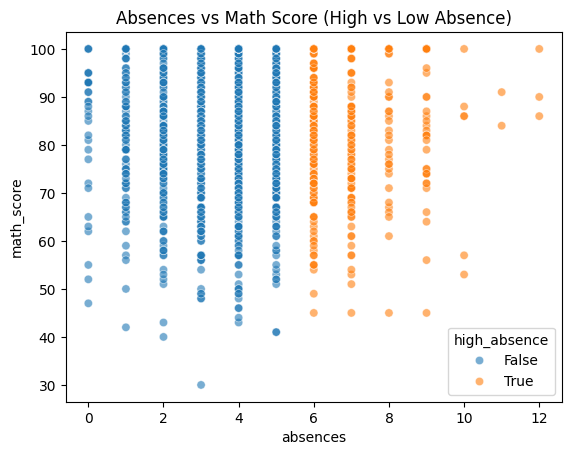

In [55]:
# create category
df["high_absence"] = df["absences"] > 5

sns.scatterplot(
    x="absences",
    y="math_score",
    hue="high_absence",
    data=df,
    alpha=0.6
)

plt.title("Absences vs Math Score (High vs Low Absence)")
plt.show()

### **Insight: High vs Low Absence Impact**

**Students with low absences (blue) show more consistent academic performance, while students with high absences (orange) display greater variability in scores. Although some high-absence students still perform well, the inconsistency suggests that frequent absences can negatively affect learning stability rather than directly determining performance.**

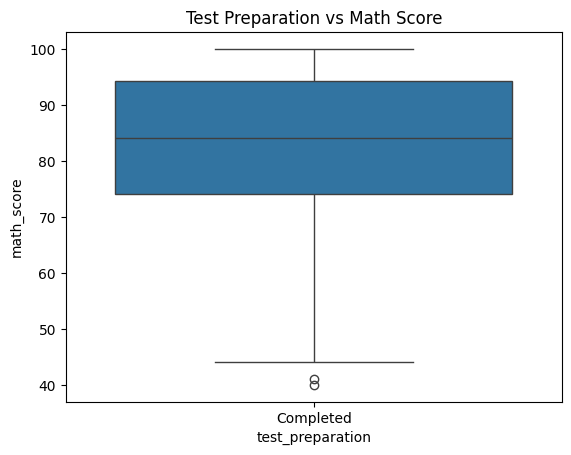

In [53]:
sns.boxplot(x="test_preparation", y="math_score", data=df)
plt.title("Test Preparation vs Math Score")
plt.show()

### **Role of Test Preparation**

**Students who have completed test preparation courses outperform those who have not. The difference in performance indicates that structured preparation helps reinforce concepts and improves exam readiness. This highlights the importance of guided learning in academic success.**

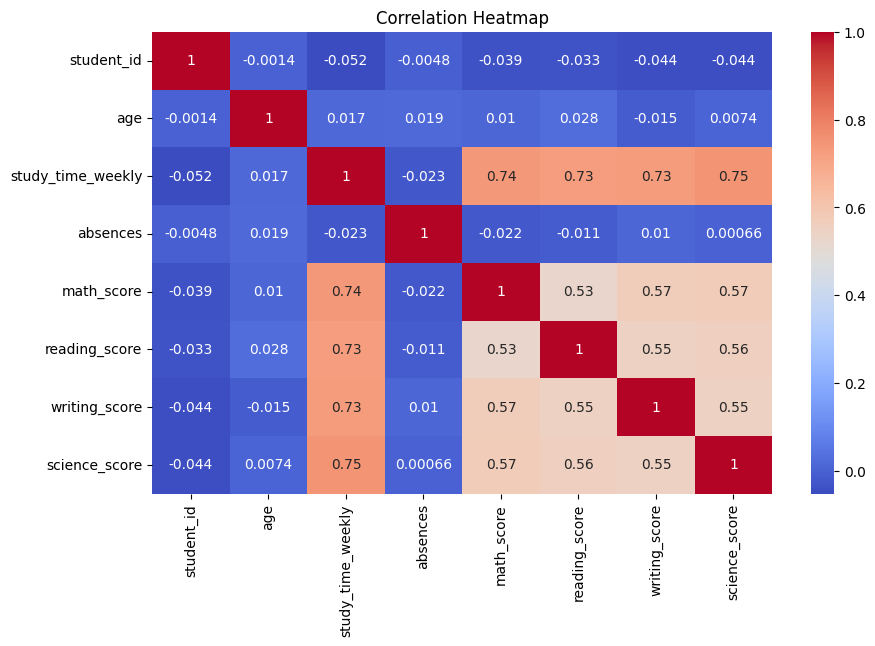

In [45]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### **Correlation Between Subjects**

**There is a strong positive correlation between reading and writing scores, indicating that students who perform well in one language-based subject tend to perform well in others. This suggests that language proficiency skills are interconnected and develop together.**

In [ ]:
def recommend(student):

    if pd.isna(student["test_preparation"]):
        test_prep = "missing"
    else:
        test_prep = student["test_preparation"].lower()

    if student["math_score"] < 50 and student["absences"] > 10:
        return "High Risk: Improve attendance and review fundamentals"
    
    elif student["math_score"] < 50:
        return "Revise the basics and practice more questions"
    
    elif student["absences"] > 10:
        return "Reduce absences and maintain consistency"
    
    elif test_prep != "completed":
        return "complete test preparation to improve performance"
    else:
        return "keep up the good work and try advanced problems"
    

### **Insight: Personalized Recommendation Strategy**

**The recommendation system is designed to identify students' weaknesses based on multiple academic factors, including performance, attendance, and preparation level. Instead of relying on a single metric, the system prioritizes combined conditions to detect high-risk students more accurately.**

**Students with both low scores and high absences are classified as high-risk, indicating that both academic gaps and irregular attendance are affecting their performance. Students with only low scores are guided to strengthen their conceptual understanding, while those with high absences are advised to improve consistency.**

**Additionally, students who have not completed test preparation are encouraged to do so, highlighting the importance of structured learning. High-performing students are directed towards advanced practice, ensuring continuous growth.**

**This rule-based approach ensures that recommendations are not generic but tailored to individual student needs, making the system more effective and practical.**

In [58]:

df["recommendation"] = df.apply(recommend, axis=1)

print(df.head(5))


   student_id course_id  age gender ethnicity  study_time_weekly  absences  \
0           1      C104   20   Male   Group C                 13         2   
1           2      C105   18   Male   Group B                 13        12   
2           3      C103   20   Male   Group A                  9         2   
3           4      C105   19   Male   Group C                 15         2   
4           5      C105   17   Male   Group B                 12         2   

  test_preparation  math_score  reading_score  writing_score  science_score  \
0        Completed          99             96             83             86   
1        Completed          86            100             68             85   
2              NaN          83             82             87             67   
3        Completed          96            100            100            100   
4              NaN          89             77             83             81   

  extracurricular learning_style  \
0             Yes   

### **Insight: Recommendation Generation**

**The recommendation logic is applied to each student record to generate personalized suggestions based on performance, attendance, and preparation. This converts raw data into actionable insights, making the system practically useful.**

In [59]:
df[["math_score", "absences", "test_preparation", "recommendation"]].head(10)

,math_score,absences,test_preparation,recommendation
0,99,2,Completed,keep up the good work and try advanced problems
1,86,12,Completed,Reduce absences and maintain consistency
2,83,2,NaN,complete test preparation to improve performance
3,96,2,Completed,keep up the good work and try advanced problems
4,89,2,NaN,complete test preparation to improve performance
5,100,9,Completed,keep up the good work and try advanced problems
6,89,1,Completed,keep up the good work and try advanced problems
7,74,4,NaN,complete test preparation to improve performance
8,71,7,NaN,complete test preparation to improve performance
9,85,3,Completed,keep up the good work and try advanced problems


### **Sample Recommendation Output**

**The table above demonstrates how the system generates personalized recommendations based on each student's academic performance, attendance, and preparation level. It highlights the practical application of the model in providing targeted guidance.**